<a href="https://colab.research.google.com/github/AnanyaAsthana/Digital-Image-Processing/blob/main/DIP_LAB_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

Saving image.jpg to image.jpg


(np.float64(-0.5), np.float64(367.5), np.float64(179.5), np.float64(-0.5))

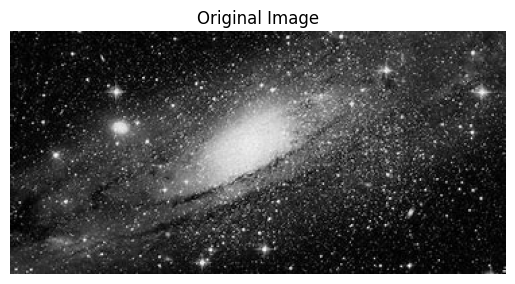

In [ ]:
uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0],0)

plt.imshow(img,cmap='gray')
plt.title("Original Image")
plt.axis("off")

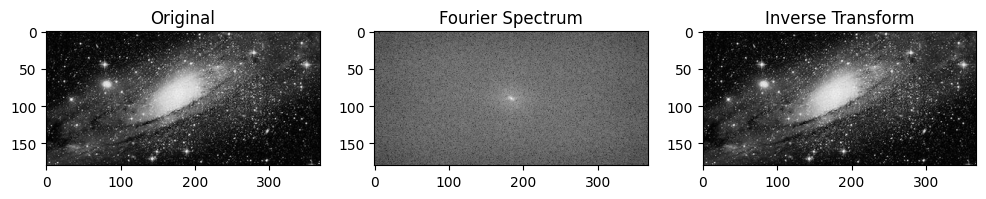

In [ ]:
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

magnitude = 20*np.log(np.abs(fshift)+1)

# inverse
ishift = np.fft.ifftshift(fshift)
inverse = np.fft.ifft2(ishift)
inverse = np.abs(inverse)

plt.figure(figsize=(12,4))

plt.subplot(131)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(132)
plt.imshow(magnitude,cmap='gray')
plt.title("Fourier Spectrum")

plt.subplot(133)
plt.imshow(inverse,cmap='gray')
plt.title("Inverse Transform")

plt.show()

In [ ]:
def distance_matrix(shape):
    rows, cols = shape
    crow, ccol = rows//2 , cols//2

    D = np.zeros((rows,cols))

    for u in range(rows):
        for v in range(cols):
            D[u,v] = np.sqrt((u-crow)**2 + (v-ccol)**2)

    return D

In [ ]:
def ideal_lpf(shape, D0):

    D = distance_matrix(shape)
    H = np.zeros(shape)

    H[D<=D0] = 1

    return H

In [ ]:
def butterworth_lpf(shape, D0, n=2):

    D = distance_matrix(shape)

    H = 1/(1 + (D/D0)**(2*n))

    return H

In [ ]:
def gaussian_lpf(shape, D0):

    D = distance_matrix(shape)

    H = np.exp(-(D**2)/(2*(D0**2)))

    return H

In [ ]:
def apply_filter(img, H):

    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)

    filtered = fshift * H

    ishift = np.fft.ifftshift(filtered)
    img_back = np.fft.ifft2(ishift)
    img_back = np.abs(img_back)

    return img_back

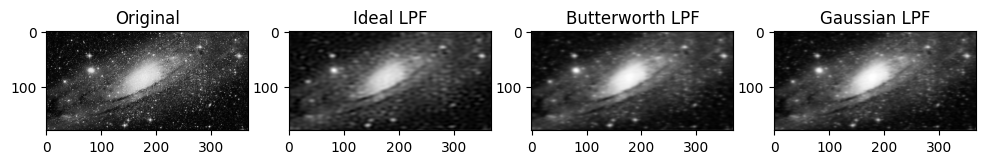

In [ ]:
D0 = 30

H1 = ideal_lpf(img.shape, D0)
H2 = butterworth_lpf(img.shape, D0)
H3 = gaussian_lpf(img.shape, D0)

i1 = apply_filter(img,H1)
i2 = apply_filter(img,H2)
i3 = apply_filter(img,H3)

plt.figure(figsize=(12,4))

plt.subplot(141);plt.imshow(img,cmap='gray');plt.title("Original")
plt.subplot(142);plt.imshow(i1,cmap='gray');plt.title("Ideal LPF")
plt.subplot(143);plt.imshow(i2,cmap='gray');plt.title("Butterworth LPF")
plt.subplot(144);plt.imshow(i3,cmap='gray');plt.title("Gaussian LPF")

plt.show()

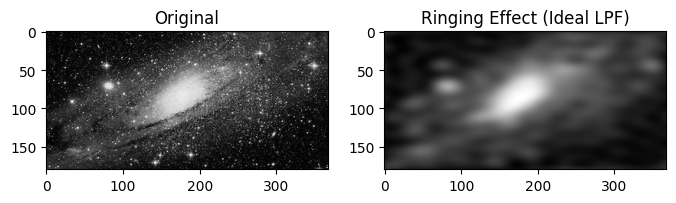

In [ ]:
D0 = 10

H = ideal_lpf(img.shape, D0)
ring = apply_filter(img,H)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(ring,cmap='gray')
plt.title("Ringing Effect (Ideal LPF)")

plt.show()

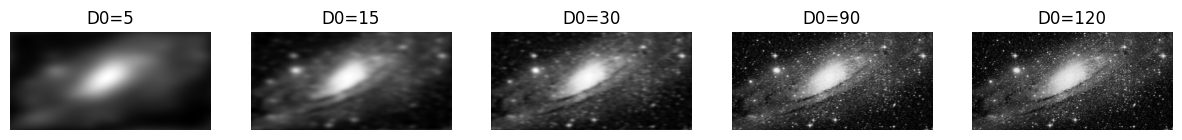

In [ ]:
cutoffs = [5,15,30,90,120]

plt.figure(figsize=(15,3))

for i,D0 in enumerate(cutoffs):

    H = butterworth_lpf(img.shape, D0,2)
    result = apply_filter(img,H)

    plt.subplot(1,5,i+1)
    plt.imshow(result,cmap='gray')
    plt.title("D0="+str(D0))
    plt.axis('off')

plt.show()

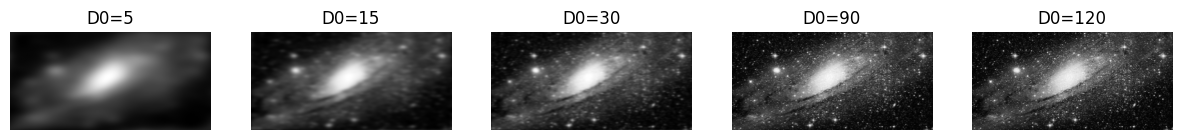

In [ ]:
cutoffs = [5,15,30,90,120]

plt.figure(figsize=(15,3))

for i,D0 in enumerate(cutoffs):

    H = gaussian_lpf(img.shape, D0)
    result = apply_filter(img,H)

    plt.subplot(1,5,i+1)
    plt.imshow(result,cmap='gray')
    plt.title("D0="+str(D0))
    plt.axis('off')

plt.show()

In [ ]:
def ideal_hpf(shape,D0):
    return 1 - ideal_lpf(shape,D0)

def butterworth_hpf(shape,D0,n=2):
    return 1 - butterworth_lpf(shape,D0,n)

def gaussian_hpf(shape,D0):
    return 1 - gaussian_lpf(shape,D0)

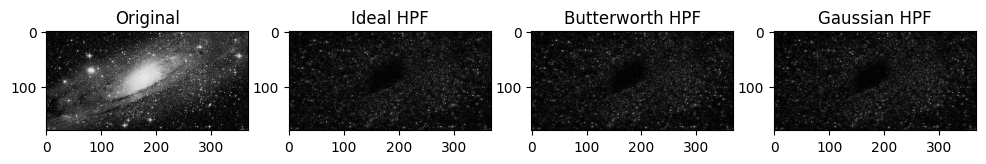

In [ ]:
D0 = 30

H1 = ideal_hpf(img.shape,D0)
H2 = butterworth_hpf(img.shape,D0)
H3 = gaussian_hpf(img.shape,D0)

i1 = apply_filter(img,H1)
i2 = apply_filter(img,H2)
i3 = apply_filter(img,H3)

plt.figure(figsize=(12,4))

plt.subplot(141);plt.imshow(img,cmap='gray');plt.title("Original")
plt.subplot(142);plt.imshow(i1,cmap='gray');plt.title("Ideal HPF")
plt.subplot(143);plt.imshow(i2,cmap='gray');plt.title("Butterworth HPF")
plt.subplot(144);plt.imshow(i3,cmap='gray');plt.title("Gaussian HPF")

plt.show()

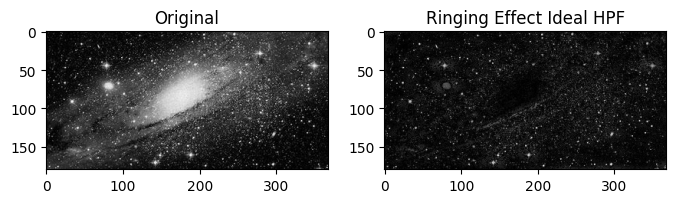

In [ ]:
D0 = 10

H = ideal_hpf(img.shape,D0)
result = apply_filter(img,H)

plt.figure(figsize=(8,4))

plt.subplot(121)
plt.imshow(img,cmap='gray')
plt.title("Original")

plt.subplot(122)
plt.imshow(result,cmap='gray')
plt.title("Ringing Effect Ideal HPF")

plt.show()

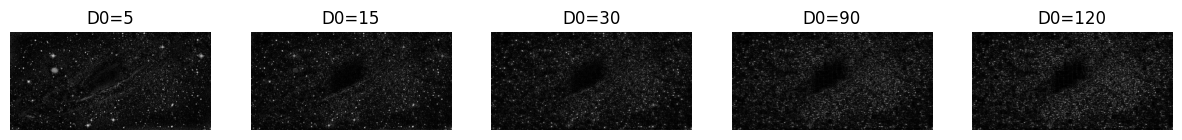

In [ ]:
cutoffs = [5,15,30,90,120]

plt.figure(figsize=(15,3))

for i,D0 in enumerate(cutoffs):

    H = butterworth_hpf(img.shape,D0,2)
    result = apply_filter(img,H)

    plt.subplot(1,5,i+1)
    plt.imshow(result,cmap='gray')
    plt.title("D0="+str(D0))
    plt.axis('off')

plt.show()

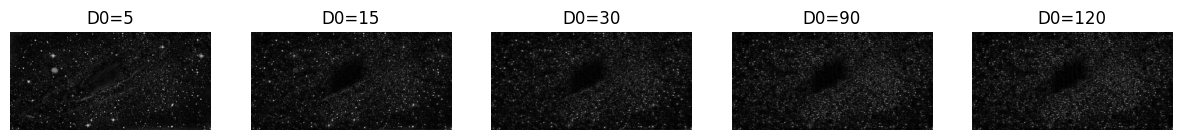

In [ ]:
cutoffs = [5,15,30,90,120]

plt.figure(figsize=(15,3))

for i,D0 in enumerate(cutoffs):

    H = gaussian_hpf(img.shape,D0)
    result = apply_filter(img,H)

    plt.subplot(1,5,i+1)
    plt.imshow(result,cmap='gray')
    plt.title("D0="+str(D0))
    plt.axis('off')

plt.show()